# Análisis de Ventas de Videojuegos

# 1. Open the file

In [ ]:
# Reading the game DataSet

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/datasets/games.csv')

In [ ]:
# Take df info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


# 2. Preparing Data

### Reemplaza los nombres de las columnas (ponlos en minúsculas).

In [ ]:
# Columns names in lower case
lower_columns = []
for column in df.columns:
    lower_columns.append(column.lower())

df.columns = lower_columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


### Convierte los datos en los tipos necesarios.

In [ ]:
# Changin data type of any column data

In [ ]:
## Analyzing some values with head
df.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [ ]:
df['platform'] = df['platform'].astype('category')
df['year_of_release'] = df['year_of_release'].astype('Int64')
df['genre'] = df['genre'].astype('category')
df['critic_score'] = df['critic_score'].astype('Int64')
#df['user_score'] = df['user_score'].astype('float64')
df['rating'] = df['rating'].astype('category')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   name             16713 non-null  object  
 1   platform         16715 non-null  category
 2   year_of_release  16446 non-null  Int64   
 3   genre            16713 non-null  category
 4   na_sales         16715 non-null  float64 
 5   eu_sales         16715 non-null  float64 
 6   jp_sales         16715 non-null  float64 
 7   other_sales      16715 non-null  float64 
 8   critic_score     8137 non-null   Int64   
 9   user_score       10014 non-null  object  
 10  rating           9949 non-null   category
dtypes: Int64(2), category(3), float64(4), object(2)
memory usage: 1.1+ MB


### Explica por qué rellenaste los valores ausentes como lo hiciste o por qué decidiste dejarlos en blanco.

In [ ]:
df['name'].fillna('Others', inplace=True)

# Calcular medianas por plataforma
median_years = df.groupby("platform")["year_of_release"].median()

# Recorrer cada plataforma y rellenar nulos
for platform, median in median_years.items():
    mask = (df["platform"] == platform) & (df["year_of_release"].isna())
    df.loc[mask, "year_of_release"] = median.astype(int)

df['genre'] = df['genre'].cat.add_categories(['Others'])
df['genre'].fillna('Others', inplace=True)
# df['critic_score'].median() = 71
# df['critic_score'].mean() = 69
# df['critic_score'].describe()
# df['critic_score'].fillna(df['critic_score'].mean().astype(int), inplace=True)
df['rating'].fillna('RP', inplace=True)

##### Las columnas en las que cambié el tipo de dato son:
##### plataforma como categoría. Lo cambié para mejorar el rendimiento de ciertas operaciones y para optimizarlas.
##### año_de_lanzamiento. Lo cambié para mostrar los datos de forma más clara, ya que el año siempre es un dato entero.
##### género y calificación. También cambié su tipo de dato a categoría por la misma razón que en las otras columnas.
##### critic_score mantendrá su tipo de dato porque tiene un valor por determinar que es una cadena.

### ¿Por qué crees que los valores están ausentes? Brinda explicaciones posibles.

##### Creo que los valores son nulos porque quizás el usuario o la persona que digitó o agregó los datos se equivocó.
##### Otra razón es que algunos valores aún no se completaron; por el momento, deberían completarse.

### Presta atención a la abreviatura TBD: significa "to be determined" (a determinar). Especifica cómo piensas manejar estos casos.

In [ ]:
# I will complete it with the median or the mean.

In [ ]:
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')
# df['user_score'].fillna(df['user_score'].median(), inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   name             16715 non-null  object  
 1   platform         16715 non-null  category
 2   year_of_release  16715 non-null  Int64   
 3   genre            16715 non-null  category
 4   na_sales         16715 non-null  float64 
 5   eu_sales         16715 non-null  float64 
 6   jp_sales         16715 non-null  float64 
 7   other_sales      16715 non-null  float64 
 8   critic_score     8137 non-null   Int64   
 9   user_score       7590 non-null   float64 
 10  rating           16715 non-null  category
dtypes: Int64(2), category(3), float64(5), object(1)
memory usage: 1.1+ MB


### Calcula las ventas totales (la suma de las ventas en todas las regiones) para cada juego y coloca estos valores en una columna separada.

In [ ]:
total_sales = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']
df.insert(8, 'total_sales', total_sales)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   name             16715 non-null  object  
 1   platform         16715 non-null  category
 2   year_of_release  16715 non-null  Int64   
 3   genre            16715 non-null  category
 4   na_sales         16715 non-null  float64 
 5   eu_sales         16715 non-null  float64 
 6   jp_sales         16715 non-null  float64 
 7   other_sales      16715 non-null  float64 
 8   total_sales      16715 non-null  float64 
 9   critic_score     8137 non-null   Int64   
 10  user_score       7590 non-null   float64 
 11  rating           16715 non-null  category
dtypes: Int64(2), category(3), float64(6), object(1)
memory usage: 1.2+ MB


# 3. Analiza los datos

### Mira cuántos juegos fueron lanzados en diferentes años. ¿Son significativos los datos de cada período?

In [ ]:
games_per_year = df.groupby('year_of_release')['name'].count()

##### In many cases yes. There are significative data since 1993.

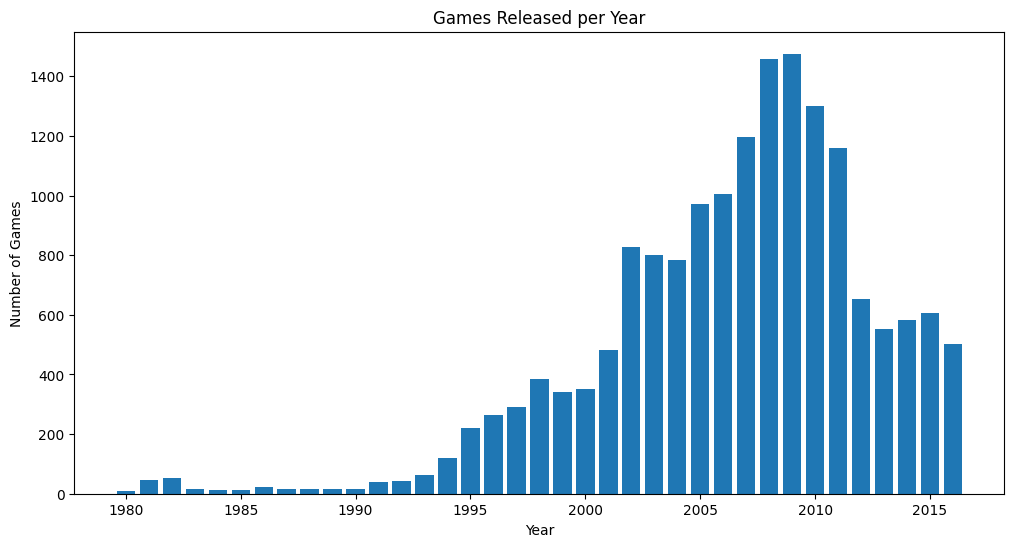

In [ ]:
plt.figure(figsize=(12,6))
plt.bar(games_per_year.index, games_per_year.values)
plt.xlabel('Year')
plt.ylabel('Number of Games')
plt.title('Games Released per Year')
plt.show()

### Observa cómo varían las ventas de una plataforma a otra. Elige las plataformas con las mayores ventas totales y construye una distribución basada en los datos de cada año. Busca las plataformas que solían ser populares pero que ahora no tienen ventas. ¿Cuánto tardan generalmente las nuevas plataformas en aparecer y las antiguas en desaparecer?

#### 1. Total sales per platform

In [ ]:
platform_sales = df.groupby('platform')['total_sales'].sum().reset_index().sort_values(by='total_sales',ascending=False)
print(platform_sales)

   platform  total_sales
16      PS2      1255.77
28     X360       971.42
17      PS3       939.65
26      Wii       907.51
4        DS       806.12
15       PS       730.86
6       GBA       317.85
18      PS4       314.14
19      PSP       294.05
13       PC       259.52
2       3DS       259.00
29       XB       257.74
5        GB       255.46
11      NES       251.05
10      N64       218.68
23     SNES       200.04
7        GC       198.93
30     XOne       159.32
0      2600        96.98
27     WiiU        82.19
20      PSV        54.07
21      SAT        33.59
8       GEN        30.77
3        DC        15.95
22      SCD         1.86
12       NG         1.44
25       WS         1.42
24     TG16         0.16
1       3DO         0.10
9        GG         0.04
14     PCFX         0.03


#### 2. Procedemnos a convertir la lista en un dataframe y a filtrar para ver las ventas mayores a 100 millones.

In [ ]:
most_platform_sales = platform_sales[platform_sales['total_sales']>100]
print(most_platform_sales)

   platform  total_sales
16      PS2      1255.77
28     X360       971.42
17      PS3       939.65
26      Wii       907.51
4        DS       806.12
15       PS       730.86
6       GBA       317.85
18      PS4       314.14
19      PSP       294.05
13       PC       259.52
2       3DS       259.00
29       XB       257.74
5        GB       255.46
11      NES       251.05
10      N64       218.68
23     SNES       200.04
7        GC       198.93
30     XOne       159.32


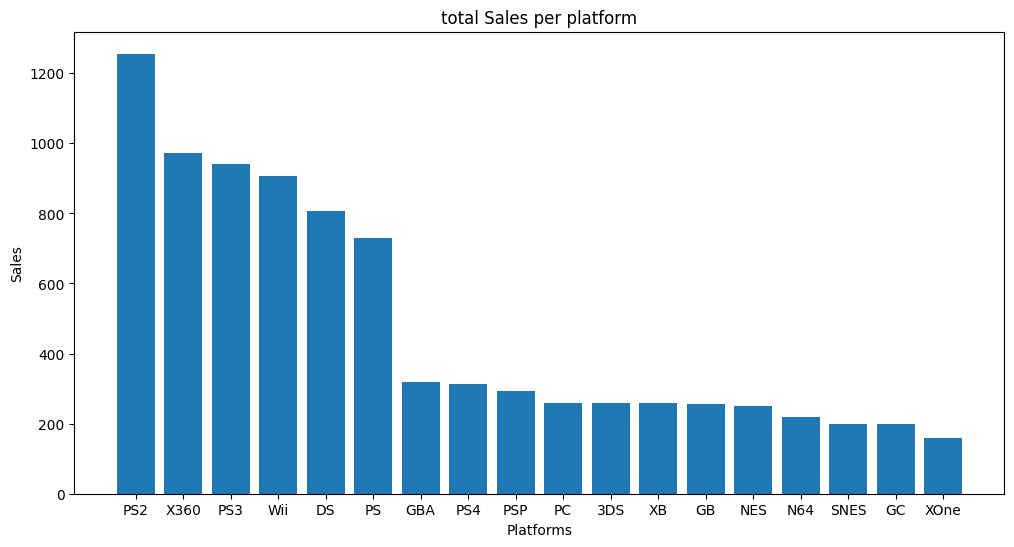

In [ ]:
plt.figure(figsize=(12,6))
plt.bar(most_platform_sales['platform'], most_platform_sales['total_sales'])
plt.xlabel('Platforms')
plt.ylabel('Sales')
plt.title('total Sales per platform')
plt.show()

#### 3. Despues de analizar el grafico, vemos que lo mas adecuado es filtrar solo las 6 mas vendidas

In [ ]:
platform_year_sales = (
    df.groupby(['platform', 'year_of_release'])['total_sales']
    .sum()
    .reset_index()
)

In [ ]:
top_platforms = (
    df.groupby('platform')['total_sales']
    .sum()
    .sort_values(ascending=False)
    .head(6)
    .index
)

df_top = platform_year_sales[platform_year_sales['platform'].isin(top_platforms)]

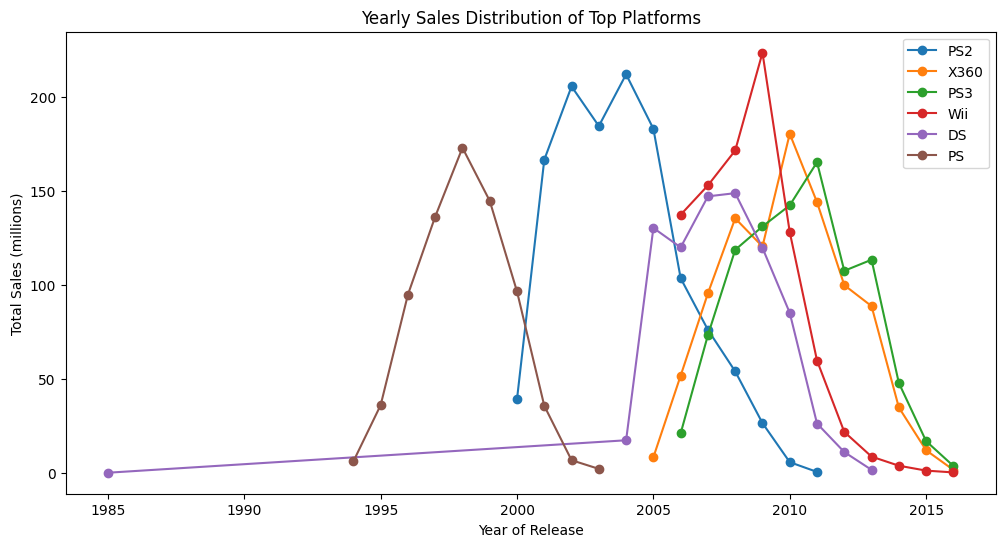

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for platform in top_platforms:
    subset = df_top[(df_top['platform'] == platform) & (df_top['total_sales'] > 0)].sort_values('year_of_release')
    plt.plot(subset['year_of_release'], subset['total_sales'], marker='o', label=platform)

plt.xlabel('Year of Release')
plt.ylabel('Total Sales (millions)')
plt.title('Yearly Sales Distribution of Top Platforms')
plt.legend()
plt.show()

#### 4. Veremos el tiemmpo de vida que tiene una consola.

In [ ]:
platform_life = (
    df_top[df_top['total_sales'] > 0]
    .groupby('platform')['year_of_release']
    .agg(['min', 'max'])
    .reset_index()
)
platform_life = platform_life.dropna()
print(platform_life)

   platform     min     max
4        DS  1985.0  2013.0
15       PS  1994.0  2003.0
16      PS2  2000.0  2011.0
17      PS3  2006.0  2016.0
26      Wii  2006.0  2016.0
28     X360  2005.0  2016.0


#### Veremos cuanto tarda una nueva consola en aparecer

In [ ]:
platform_life['lifespan'] = platform_life['max'] - platform_life['min']
print(platform_life)

   platform     min     max  lifespan
4        DS  1985.0  2013.0      28.0
15       PS  1994.0  2003.0       9.0
16      PS2  2000.0  2011.0      11.0
17      PS3  2006.0  2016.0      10.0
26      Wii  2006.0  2016.0      10.0
28     X360  2005.0  2016.0      11.0


In [ ]:
print('El promediod de vida es ',platform_life['lifespan'].mean())

El promediod de vida es  13.166666666666666


### Determina para qué período debes tomar datos. Para hacerlo mira tus respuestas a las preguntas anteriores. Los datos deberían permitirte construir un modelo para 2017.

#### Del último gráfico que veo el periodo que debería utilizar para construir un modelo es 1994 a 2016. Esto se debe a que a partir de este año parece que comienza una nueva era de consolas.

### ¿Qué plataformas son líderes en ventas? ¿Cuáles crecen y cuáles se reducen? Elige varias plataformas potencialmente rentables.

#### Las plataformas que lideran las ventas son PS2, X360, PS3, Wii, DS y PS.

### Crea un diagrama de caja para las ventas globales de todos los juegos, desglosados por plataforma. ¿Son significativas las diferencias en las ventas? ¿Qué sucede con las ventas promedio en varias plataformas? Describe tus hallazgos.

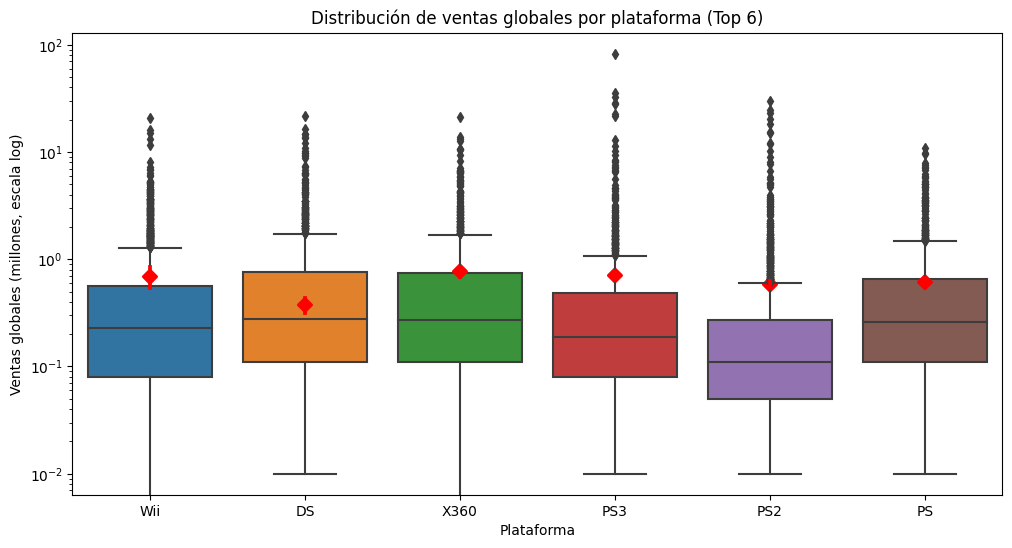

In [ ]:
import numpy as np
import seaborn as sns

df_top6 = df[df['platform'].isin(top_platforms)].copy()

# Asegurar que platform sea string normal (no categorical)
df_top6['platform'] = df_top6['platform'].astype(str)

plt.figure(figsize=(12,6))
sns.boxplot(data=df_top6, x='platform', y='total_sales',
            order=top_platforms)
sns.pointplot(data=df_top6, x="platform", y="total_sales",
              estimator=np.mean, color="red", markers="D", join=False)

plt.yscale("log")
plt.title("Distribución de ventas globales por plataforma (Top 6)")
plt.ylabel("Ventas globales (millones, escala log)")
plt.xlabel("Plataforma")
plt.show()


#### No hay diferencias abismales en la distribución típica de ventas entre plataformas, aunque puede haber diferencias pequeñas. A simple vista, las distribuciones son muy parecidas: todas las cajas (50% central de los datos) están ubicadas en un rango similar.
#### Las diferencias más notorias están en los outliers, que elevan el promedio en algunas consolas (ej. Wii, PS2).
#### En cuanto al promedio no refleja bien la tendencia central, porque está sesgado por pocos juegos con ventas enormes; la mediana es más representativa.

### Mira cómo las reseñas de usuarios y profesionales afectan las ventas de una plataforma popular (tu elección). Crea un gráfico de dispersión y calcula la correlación entre las reseñas y las ventas. Saca conclusiones.

In [ ]:
df_ps2 = df[df['platform'] == 'PS2']
df_ps2 = df_ps2[['name', 'user_score', 'critic_score', 'total_sales']]


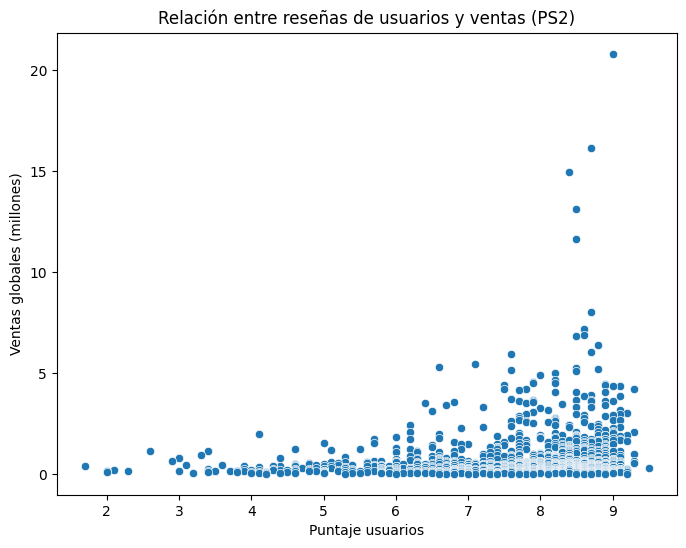

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_ps2, x='user_score', y='total_sales')
plt.title('Relación entre reseñas de usuarios y ventas (PS2)')
plt.xlabel('Puntaje usuarios')
plt.ylabel('Ventas globales (millones)')
plt.show()

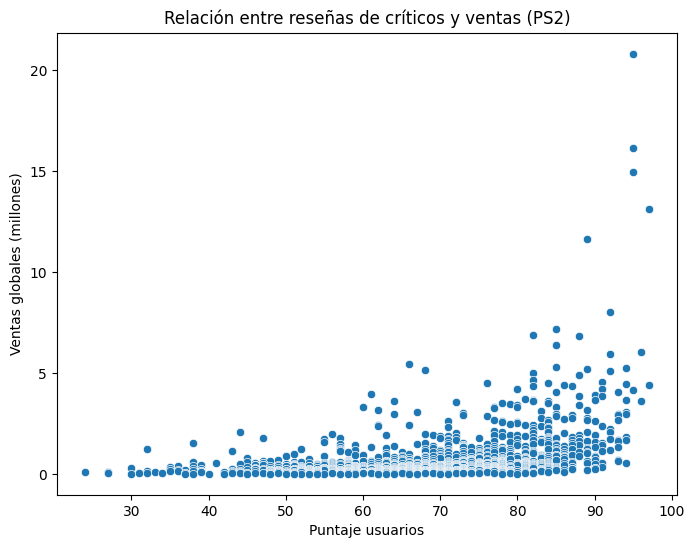

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_ps2, x='critic_score', y='total_sales')
plt.title('Relación entre reseñas de críticos y ventas (PS2)')
plt.xlabel('Puntaje usuarios')
plt.ylabel('Ventas globales (millones)')
plt.show()

In [ ]:
correlaciones = df_ps2[['user_score', 'critic_score', 'total_sales']].corr()
print(correlaciones)

              user_score  critic_score  total_sales
user_score      1.000000      0.563254     0.172866
critic_score    0.563254      1.000000     0.395435
total_sales     0.172866      0.395435     1.000000


#### Visualmente sí hay relación, sobre todo en la “cola alta” de ventas (los superventas suelen tener buenas reseñas).
#### Pero estadísticamente la correlación es débil, porque la mayoría de juegos no siguen esa regla tan claramente.

### Teniendo en cuenta tus conclusiones compara las ventas de los mismos juegos en otras plataformas.

In [ ]:
# Agrupamos por nombre del juego y contamos cuántas plataformas tiene
multi = df.groupby('name')['platform'].nunique().reset_index()

# Filtramos los que tienen más de 1 plataforma
multi = multi[multi['platform'] > 1]

print(multi.head(10))

                                                 name  platform
2                                Frozen: Olaf's Quest         2
17                             007: Quantum of Solace         6
18                       007: The World is not Enough         2
33                                  11eyes: CrossOver         2
39                   18 Wheeler: American Pro Trucker         2
42                                   187: Ride or Die         2
52  2 in 1 Combo Pack: Sonic Heroes / Super Monkey...         2
54                                2002 FIFA World Cup         3
55                   2010 FIFA World Cup South Africa         4
56                         2014 FIFA World Cup Brazil         2


#### A partir de acá, puedo tomar cualquier título que se encuentre en cualquier plataforma para poder llevar acabo el análisis. En este caso tomaré el juego 2010 FIFA World Cup South Africa y el de 007.

In [ ]:

game1 = "2010 FIFA World Cup South Africa"
df_game1 = df[df['name'] == game1][['platform','user_score','critic_score','total_sales']]
print(df_game1)


     platform  user_score  critic_score  total_sales
1634      PS3         7.8            82         1.23
2429     X360         8.1            83         0.85
4211      PSP         7.4            69         0.46
4579      Wii         6.7            70         0.43


#### Ahora es posible aplicar la correlación entre el rating y las ventas

In [ ]:
df_game1[['user_score','critic_score','total_sales']].corr()

,user_score,critic_score,total_sales
user_score,1.000000,0.840963,0.713779
critic_score,0.840963,1.000000,0.884142
total_sales,0.713779,0.884142,1.000000


In [ ]:
game2 = "007: Quantum of Solace"
df_game2 = df[df['name'] == game2][['platform','user_score','critic_score','total_sales']]
print(df_game2)

      platform  user_score  critic_score  total_sales
1285      X360         7.1            65         1.48
1785       PS3         6.6            65         1.15
3120       Wii         7.5            54         0.65
4475       PS2         NaN          <NA>         0.43
9507        DS         NaN            65         0.13
14658       PC         6.3            70         0.02


In [ ]:
df_game2[['user_score','critic_score','total_sales']].corr()

,user_score,critic_score,total_sales
user_score,1.000000,-0.904846,0.405804
critic_score,-0.904846,1.000000,-0.196899
total_sales,0.405804,-0.196899,1.000000


#### Al ver los resultados se puede ver que en ambos juegos la correlación entre las críticas y las ventas es distinta. Por un lado el juego deportivo tuvo buena correlación, pero el otro juego no. Posiblemente esté relacionado a la consola o el género de los juegos, pero es necesario hacer más análisis.

### Echa un vistazo a la distribución general de los juegos por género. ¿Qué se puede decir de los géneros más rentables? ¿Puedes generalizar acerca de los géneros con ventas altas y bajas?

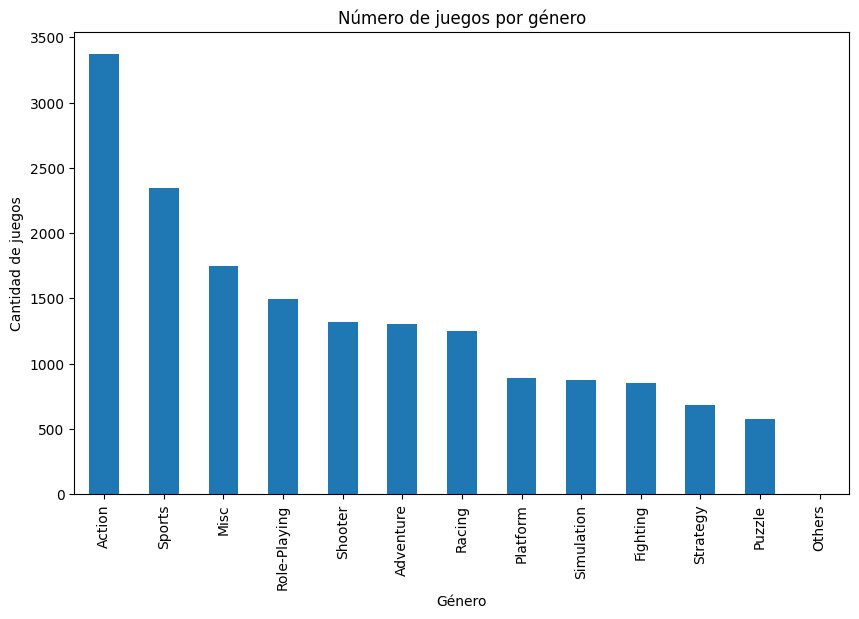

In [ ]:
df['genre'].value_counts().plot(kind='bar', figsize=(10,6))
plt.title("Número de juegos por género")
plt.xlabel("Género")
plt.ylabel("Cantidad de juegos")
plt.show()

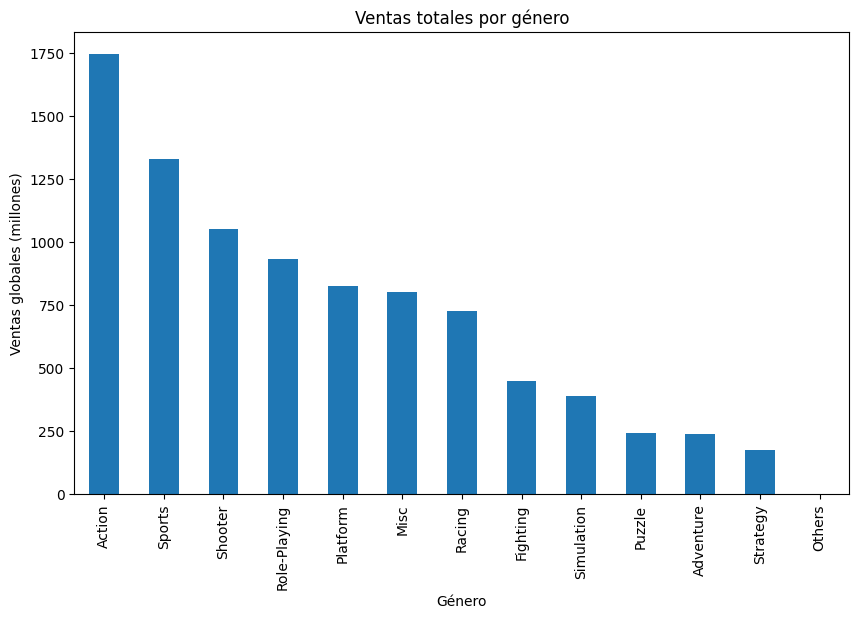

In [ ]:
df.groupby('genre')['total_sales'].sum().sort_values(ascending=False).plot(
    kind='bar', figsize=(10,6))
plt.title("Ventas totales por género")
plt.xlabel("Género")
plt.ylabel("Ventas globales (millones)")
plt.show()

#### De acuerdo a las gráficas podemos notar que Action es, por lejos, el género con más juegos lanzados (más de 3,000 títulos).
#### Así mismo, géneros como Puzzle, Strategy y Adventure tienen muy pocos juegos publicados en comparación.
#### Action también lidera en ventas globales, lo cual coincide con su gran cantidad de títulos.
#### Sports y Shooter destacan: no tienen tantos juegos como Action, pero sí concentran ventas muy altas, lo que indica que son géneros con mucha demanda y títulos muy exitosos.

# Crea un perfil de usuario para cada región

## Las cinco plataformas principales. Describe las variaciones en sus cuotas de mercado de una región a otra.

In [ ]:
# Top 5 plataformas en Norteamérica
top_na = df.groupby('platform')['na_sales'].sum().sort_values(ascending=False).head(5)
print(top_na)

platform
X360    602.47
PS2     583.84
Wii     496.90
PS3     393.49
DS      382.40
Name: na_sales, dtype: float64


In [ ]:
# Europa
top_eu = df.groupby('platform')['eu_sales'].sum().sort_values(ascending=False).head(5)
print(top_eu)

platform
PS2     339.29
PS3     330.29
X360    270.76
Wii     262.21
PS      213.61
Name: eu_sales, dtype: float64


In [ ]:
# Japón
top_jp = df.groupby('platform')['jp_sales'].sum().sort_values(ascending=False).head(5)
print(top_jp)

platform
DS      175.57
PS      139.82
PS2     139.20
SNES    116.55
3DS     100.67
Name: jp_sales, dtype: float64


#### En base a lo mostrado en las tablas, es facil distinguir que la mayor cantidad de ventas se ha producido en NA, y esto tiene mucho sentido debido a que en dicho pais existe un mayor nivel de consumismo y mayor pib que en Europa. Por otro lado en NA tambien se nota una mayor compra de videojuegos para la consola X360 lo cual tambien tiene sentido debido a que esta marca pertenece a la empresa Microsoft. Por el lado de Europa se ven mayores ventas que en  Japon y a la par aca tambien se puede apreciar una mayor demanda de los juegos de la consola de Somy. Finalmente en JP se ve que la mayoria de juegos son para consolas Niponas.

#### Los cinco géneros principales. Explica la diferencia.

In [ ]:
# Top 5 generos en Norteamérica
top_genre_na = df.groupby('genre')['na_sales'].sum().sort_values(ascending=False).head(5)
print(top_genre_na)

genre
Action      879.01
Sports      684.43
Shooter     592.24
Platform    445.50
Misc        407.27
Name: na_sales, dtype: float64


In [ ]:

top_genre_eu = df.groupby('genre')['eu_sales'].sum().sort_values(ascending=False).head(5)
print(top_genre_eu)


genre
Action     519.13
Sports     376.79
Shooter    317.34
Racing     236.51
Misc       212.74
Name: eu_sales, dtype: float64


In [ ]:
top_genre_jp = df.groupby('genre')['jp_sales'].sum().sort_values(ascending=False).head(5)
print(top_genre_jp)

genre
Role-Playing    355.41
Action          161.43
Sports          135.54
Platform        130.83
Misc            108.11
Name: jp_sales, dtype: float64


#### En cuanto a los analisis, resulta interesante ver que los gustos de los generos en NA y EU son bastante parecidos, salvo un cambio en el cuarto lugar de Platform en NA por Racing en EU luego son muy similares. Por otra parte, en JP se ve cierta diferencia con respecto a los demas lugares. En JP el genero mas vendido es de tipo Role-Playing mientras que accion tambien se cuentra listado como en EU y NA. De manera concreta parece que a nivel global Action y Sports son los preferidos y hay una tendencia marcada en JP por los de Rol.

### Si las clasificaciones de ESRB afectan a las ventas en regiones individuales.

In [ ]:
# Top 5 generos en Norteamérica
top_esrb_na = df.groupby('rating')['na_sales'].sum().sort_values(ascending=False).head(5)
print(top_esrb_na)

rating
E       1292.99
RP      1242.46
T        759.75
M        748.48
E10+     353.32
Name: na_sales, dtype: float64


In [ ]:
top_esrb_eu = df.groupby('rating')['eu_sales'].sum().sort_values(ascending=False).head(5)
print(top_esrb_eu)

rating
E       710.25
RP      613.91
M       483.97
T       427.03
E10+    188.52
Name: eu_sales, dtype: float64


In [ ]:
top_esrb_jp = df.groupby('rating')['jp_sales'].sum().sort_values(ascending=False).head(5)
print(top_esrb_jp)

rating
RP      841.96
E       198.11
T       151.40
M        64.24
E10+     40.20
Name: jp_sales, dtype: float64


#### Aca podemos observar que la clasificacion mas comprada es la E y la RP. Resulta intrigante que haya muchas compras de juegos con clasificacion pendiente, pero asumo que es por las preventas de muchos juegos. Asi mismo se ve que los juegos con clasificaciones distintas a E y RP suelen ser muy similares en todas las regiones.

# 5. Prueba las siguientes hipótesis:

### Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.

In [ ]:
from scipy import stats

xbox = df.loc[df['platform'] == 'XOne', 'user_score'].dropna()
pc = df.loc[df['platform'] == 'PC', 'user_score'].dropna()

t_stat1, p_val1 = stats.ttest_ind(xbox, pc, equal_var=False)

print("t =", round(t_stat1, 3), ", p-value =", round(p_val1, 5))

if p_val1 < 0.05:
    print("Rechazamos H0: Sí hay diferencia significativa en las calificaciones.")
else:
    print("No rechazamos H0: No hay evidencia de diferencia en las calificaciones.")

t = -4.653 , p-value = 0.0
Rechazamos H0: Sí hay diferencia significativa en las calificaciones.


### Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.

In [ ]:
accion = df.loc[df['genre'] == 'Action', 'user_score'].dropna()
deportes = df.loc[df['genre'] == 'Sports', 'user_score'].dropna()

t_stat2, p_val2 = stats.ttest_ind(accion, deportes, equal_var=False)

print("t =", round(t_stat2, 3), ", p-value =", round(p_val2, 5))

if p_val2 < 0.05:
    print("Rechazamos H0: Sí hay diferencia significativa en las calificaciones.")
else:
    print("No rechazamos H0: No hay evidencia de diferencia en las calificaciones.")

t = 1.577 , p-value = 0.11484
No rechazamos H0: No hay evidencia de diferencia en las calificaciones.


### Explica: Cómo formulaste las hipótesis nula y alternativa.

#### Para realizar las formulaciones me base en las premisas dadas en el enunciado. Ene el caso de la primera se dice que las calificaciones para dos plataformas son las mismas. Tomando esta como la nula, y la alternativa seria que si hay diferencias. Para la segunda hipotesis, se nos dice que las calificaciones de dos generos en especifico son distintas. Para tomar la alternativa simplemente negue la primera, es decir verificar si no son diferentes.

### Explica: Qué criterio utilizaste para probar las hipótesis y por qué.

#### Utilicé una prueba t de Student para muestras independientes (scipy.stats.ttest_ind) porque:
#### Se trata de comparar dos grupos distintos (ejemplo: Xbox One vs PC, o Acción vs Deportes).
#### La variable de interés (user_score) es numérica y continua, adecuada para este test.
#### La prueba t evalúa si las diferencias observadas entre medias son estadísticamente significativas o si pueden deberse al azar.

# 6. Escribe una conclusión general

El análisis del dataset de videojuegos permitió identificar patrones importantes en la industria. Primero, se observó que las ventas varían considerablemente según la región, lo que evidencia que las preferencias de los consumidores no son homogéneas a nivel global. Asimismo, ciertos géneros y plataformas se consolidan como líderes de mercado, mientras que otros tienen una presencia mucho más limitada.

En cuanto a la relación entre las calificaciones y las ventas, se comprobó que las reseñas de críticos y usuarios ejercen un impacto en el desempeño comercial de los juegos, aunque no siempre de manera determinante. Las pruebas de hipótesis aplicadas mediante la prueba t de Student mostraron que existen diferencias estadísticamente significativas entre plataformas y géneros en términos de puntuación, lo cual sugiere que la calidad percibida no es uniforme en todos los segmentos.

En general, el estudio confirma que la combinación de factores como plataforma, género y valoración crítica influyen en el éxito comercial de un título. Estos resultados refuerzan la importancia de segmentar estrategias de marketing y desarrollo según las características de cada mercado y perfil de jugador.